In [1]:
import os
import numpy as np
from pathlib import Path
from matplotlib import rc
from matplotlib import font_manager
import matplotlib.pyplot as plt
import cortex as cx
from prf_expect.utils import io
from prf_expect.utils.viz import desaturate_palette, sample_cmap, cm_to_inch

In [2]:
cwd = os.getcwd()
figure_result_dir = Path(cwd).parent / "figures"
subjects = ["sub-001", "sub-002", "sub-004", "sub-005", "sub-007", "sub-009", "sub-012"]
font_dirs = [Path(cwd).parent.parent.parent / "arial"]
font_files = font_manager.findSystemFonts(fontpaths=font_dirs)
for font_file in font_files:
    font_manager.fontManager.addfont(font_file)

rc("pdf", fonttype=42, use14corefonts=False)
rc("axes", linewidth=0.5)
rc("font", **{"family": "Arial"})
rc("text", usetex=False)
rc("xtick", labelsize=6)
rc("ytick", labelsize=6)
rc("axes", labelsize=7)
rc("legend", fontsize=6)

plt.rcParams["xtick.major.width"] = 0.5
plt.rcParams["ytick.major.width"] = 0.5
plt.rcParams["xtick.major.size"] = 2
plt.rcParams["ytick.major.size"] = 2
plt.rcParams["xtick.minor.width"] = 0.5
plt.rcParams["ytick.minor.width"] = 0.5
plt.rcParams["xtick.minor.size"] = 1
plt.rcParams["ytick.minor.size"] = 1

# set up figure parameters
markeredgecolor = ".4"
bar_linewidth = 0.5
bar_alpha = 0.7
xticks_rotation = 45
marker = "s"
marker_edge_width = 0.5
markersize = 3 / 2.54
errorbar_linewidth = 0.5
errorbar_capsize = 2 / 2.54
errorbar_capthick = 0.5

In [3]:
settings = io.load_settings()
data_dir = Path(settings['general']['data_dir'], "data")

Loading settings from /Users/dionysus/Library/CloudStorage/OneDrive-Personal/Workbench/pRF_expect_pub/pRF_expect_analysis/prf_expect/settings.yml


In [4]:
surprise_analysis_type = 'TRMI-type1'
beta_omits = []
beta_spars = []
TRMIs = []
for subject in subjects:
    analysis_result_dir = Path(data_dir) / f"derivatives/prf_data/{subject}/ses-1/{surprise_analysis_type}"
    analysis_result_dir = Path(analysis_result_dir)
    if surprise_analysis_type == 'TRMI-type1':
        beta_omit_fn = analysis_result_dir / f"{subject}_ses-1_space-fsaverage_surprise-viol_beta_omitdm.npy"
        beta_omit_sub = np.load(beta_omit_fn, allow_pickle=True)
        beta_omits.append(beta_omit_sub)
        beta_spar_fn = analysis_result_dir / f"{subject}_ses-1_space-fsaverage_surprise-viol_beta_sparsedm.npy"
        beta_spar_sub = np.load(beta_spar_fn, allow_pickle=True)
        beta_spars.append(beta_spar_sub)
        TRMI = np.load(analysis_result_dir / f"{subject}_ses-1_space-fsaverage_surprise-TRMI.npy", allow_pickle=True)
        TRMIs.append(TRMI)
    if surprise_analysis_type == 'TRMI-type2':
        beta_omit_fn = analysis_result_dir / f"{subject}_ses-1_space-fsaverage_surprise-omit_beta_omitdm.npy"
        beta_omit_sub = np.load(beta_omit_fn, allow_pickle=True)
        beta_omits.append(beta_omit_sub)
        beta_spar_fn = analysis_result_dir / f"{subject}_ses-1_space-fsaverage_surprise-viol_beta_sparsedm.npy"
        beta_spar_sub = np.load(beta_spar_fn, allow_pickle=True)
        beta_spars.append(beta_spar_sub)
        TRMI = np.load(analysis_result_dir / f"{subject}_ses-1_space-fsaverage_surprise-TRMI.npy", allow_pickle=True)
        TRMIs.append(TRMI)
    if surprise_analysis_type == 'TRMI-type3':
        beta_omit_fn = analysis_result_dir / f"{subject}_ses-1_space-fsaverage_surprise-omit_beta_omitdm.npy"
        beta_omit_sub = np.load(beta_omit_fn, allow_pickle=True)
        beta_omits.append(beta_omit_sub)
        beta_spar_fn = analysis_result_dir / f"{subject}_ses-1_space-fsaverage_surprise-spar_beta_spardm.npy"
        beta_spar_sub = np.load(beta_spar_fn, allow_pickle=True)
        beta_spars.append(beta_spar_sub)
        TRMI = np.load(analysis_result_dir / f"{subject}_ses-1_space-fsaverage_surprise-TRMI.npy", allow_pickle=True)
        TRMIs.append(TRMI)
    if surprise_analysis_type == 'TRMI-type4':
        beta_omit_fn = analysis_result_dir / f"{subject}_ses-1_space-fsaverage_surprise-viol_beta_omitdm.npy"
        beta_omit_sub = np.load(beta_omit_fn, allow_pickle=True)
        beta_omits.append(beta_omit_sub)
        beta_spar_fn = analysis_result_dir / f"{subject}_ses-1_space-fsaverage_surprise-spar_beta_spardm.npy"
        beta_spar_sub = np.load(beta_spar_fn, allow_pickle=True)
        beta_spars.append(beta_spar_sub)
        TRMI = np.load(analysis_result_dir / f"{subject}_ses-1_space-fsaverage_surprise-TRMI.npy", allow_pickle=True)
        TRMIs.append(TRMI)

beta_omits = np.array(beta_omits, dtype=float)
beta_omits[~np.isfinite(beta_omits)] = np.nan

beta_spars = np.array(beta_spars, dtype=float)
beta_spars[~np.isfinite(beta_spars)] = np.nan

# remove outliers based on median and only keep values within 3 IQR (per subject)
beta_omits_median = np.nanmedian(beta_omits, axis=1)
beta_omits_iqr = np.nanpercentile(beta_omits, 75, axis=1) - np.nanpercentile(beta_omits, 25, axis=1)
beta_omits_upper_bound = (beta_omits_median + 3 * beta_omits_iqr)[:, np.newaxis]
beta_omits_lower_bound = (beta_omits_median - 3 * beta_omits_iqr)[:, np.newaxis]
beta_omits[beta_omits > beta_omits_upper_bound] = np.nan
beta_omits[beta_omits < beta_omits_lower_bound] = np.nan
beta_spars_median = np.nanmedian(beta_spars, axis=1)
beta_spars_iqr = np.nanpercentile(beta_spars, 75, axis=1) - np.nanpercentile(beta_spars, 25, axis=1)
beta_spars_upper_bound = (beta_spars_median + 3 * beta_spars_iqr)[:, np.newaxis]
beta_spars_lower_bound = (beta_spars_median - 3 * beta_spars_iqr)[:, np.newaxis]
beta_spars[beta_spars > beta_spars_upper_bound] = np.nan
beta_spars[beta_spars < beta_spars_lower_bound] = np.nan


In [5]:
comb_ROIs = True
ROIs_list_long = ('V1', 'V2', 'V3', 'V3A', 'V3B', 'V4', 'LO1', 'LO2', 'VO1', 
        'VO2', 'hMT', 'MST', 'IPS0', 'IPS1', 'IPS2', 'IPS3', 'IPS4', 'IPS5')
roi_verts = cx.get_roi_verts('fsaverage', ROIs_list_long)
combined_roi_verts = {}
combined_roi_verts["V1"] = roi_verts["V1"]
combined_roi_verts["V2"] = roi_verts["V2"]
combined_roi_verts["V3"] = roi_verts["V3"]
combined_roi_verts["V3AB"] = np.concatenate((roi_verts["V3A"], roi_verts["V3B"]))
combined_roi_verts["V4"] = roi_verts["V4"]
combined_roi_verts["LO"] = np.concatenate((roi_verts["LO1"], roi_verts["LO2"]))
combined_roi_verts["TO"] = np.concatenate((roi_verts["hMT"], roi_verts["MST"]))
combined_roi_verts["VO"] = np.concatenate((roi_verts["VO1"], roi_verts["VO2"]))
combined_roi_verts["earlyIPS"] = np.concatenate((roi_verts["IPS0"], 
                                            roi_verts["IPS1"], 
                                            roi_verts["IPS2"],))
combined_roi_verts["lateIPS"] = np.concatenate((roi_verts["IPS3"], 
                                            roi_verts["IPS4"], 
                                            roi_verts["IPS5"]))
if comb_ROIs == True:
    rois = combined_roi_verts
else:
    rois = roi_verts

ROIs_list = list(rois.keys())
vis_verts = np.array([], dtype=int)
for iroi in rois:
    vis_verts = np.concatenate((vis_verts, rois[iroi]))

In [6]:
roi = "V1"

In [7]:
roi_verts = cx.get_roi_verts('fsaverage', (roi,))
roi_indices = roi_verts[roi]
nr_best_voxels = 200
rsq_threshold = 0.0

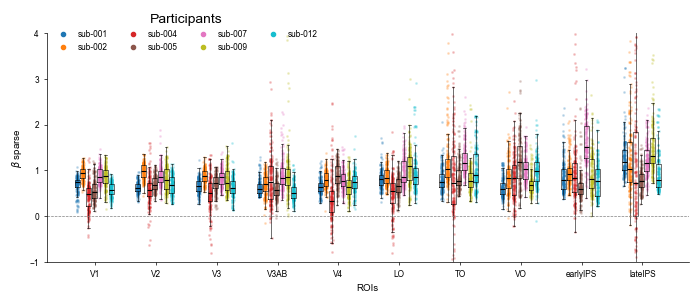

In [8]:
# plot beta sparsity distributions for all subjects across all ROIs in one figure
roi_names = ROIs_list if 'ROIs_list' in globals() else [roi]
n_rois = len(roi_names)
n_subs = len(subjects)
sub_colors = sample_cmap('tab10', n_subs)
rng = np.random.default_rng(42)

# load cross-validated R² once per subject
rsq_all_subs = []
for sub in subjects:
    analysis_result_dir = Path(data_dir) / f"derivatives/prf_data/{sub}/ses-1/{surprise_analysis_type}"
    rsq_sub = np.load(analysis_result_dir / f"{sub}_ses-1_space-fsaverage_surprise-viol_rsq.npy", allow_pickle=True)
    rsq_sub[np.isnan(rsq_sub)] = 0
    rsq_sub[np.isinf(rsq_sub)] = 0
    rsq_all_subs.append(rsq_sub)

fig, ax = plt.subplots(figsize=cm_to_inch(18, 8))
roi_positions = np.arange(n_rois)
subject_offsets = np.linspace(-0.28, 0.28, n_subs)

for roi_idx, roi_name in enumerate(roi_names):
    roi_indices = rois[roi_name] if 'rois' in globals() else cx.get_roi_verts('fsaverage', (roi_name,))[roi_name]
    if len(roi_indices) == 0:
        continue

    for i, sr in enumerate(beta_spars):
        rsq_sub = rsq_all_subs[i]
        rsq_roi = rsq_sub[roi_indices]

        keep_mask = rsq_roi > rsq_threshold
        if not np.any(keep_mask):
            continue

        roi_indices_kept = roi_indices[keep_mask]
        rsq_kept = rsq_roi[keep_mask]

        if len(roi_indices_kept) > nr_best_voxels:
            best_idx_local = np.argsort(rsq_kept)[::-1][:nr_best_voxels]
            best_voxel_indices = roi_indices_kept[best_idx_local]
        else:
            best_voxel_indices = roi_indices_kept

        valid = sr[best_voxel_indices]
        valid = valid[np.isfinite(valid)]
        if len(valid) == 0:
            continue

        pos = roi_positions[roi_idx] + subject_offsets[i]

        jitter = rng.uniform(-0.015, 0.015, size=len(valid))
        ax.scatter(
            pos - 0.02 + jitter,
            valid,
            s=1.2,
            color=sub_colors[i],
            alpha=0.2,
            zorder=2,
            rasterized=True
        )

        # Narrow line-only boxplot (no fill color)
        ax.boxplot(
            valid,
            positions=[pos - 0.02],
            widths=0.08,
            patch_artist=False,
            showfliers=False,
            medianprops=dict(color='k', linewidth=0.8),
            whiskerprops=dict(color='k', linewidth=0.4),
            capprops=dict(color='k', linewidth=0.4),
            boxprops=dict(color='k', linewidth=0.4)
        )

ax.set_xticks(roi_positions)
ax.set_xticklabels(roi_names, rotation=0)
ax.set_ylabel('$\\beta$ sparse')
ax.set_xlabel('ROIs')
ax.axhline(0, color='gray', ls='--', lw=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim(-1, 4)

# legend for participant colors
legend_handles = [
    plt.Line2D([0], [0], marker='o', linestyle='None', color=sub_colors[i], label=subjects[i], markersize=3)
    for i in range(n_subs)
 ]
ax.legend(handles=legend_handles, title='Participants', ncol=4, frameon=False, loc='upper left', bbox_to_anchor=(0, 1.12))

fig.tight_layout()
plt.show()
fig.savefig(
    figure_result_dir / f"group_analysis-{surprise_analysis_type}_space-fsaverage_desc-prf_viz_allrois_hq-vertex_beta_sparsity-crossvalidatedrsq.png",
    dpi=600,
    bbox_inches='tight'
)

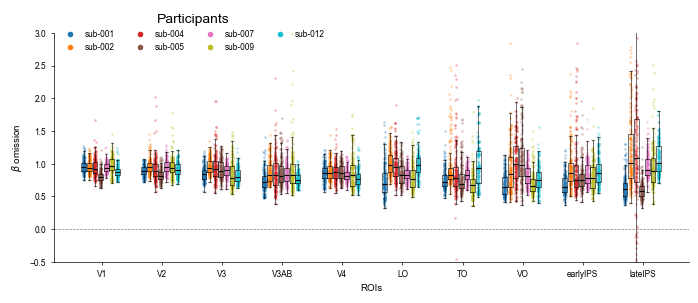

In [ ]:
# plot beta omission distributions for all subjects across all ROIs in one figure
roi_names = ROIs_list if 'ROIs_list' in globals() else [roi]
n_rois = len(roi_names)
n_subs = len(subjects)
sub_colors = sample_cmap('tab10', n_subs)
rng = np.random.default_rng(42)

# load cross-validated R² once per subject
rsq_all_subs = []
for sub in subjects:
    analysis_result_dir = Path(data_dir) / f"derivatives/prf_data/{sub}/ses-1/{surprise_analysis_type}"
    rsq_sub = np.load(analysis_result_dir / f"{sub}_ses-1_space-fsaverage_surprise-viol_rsq.npy", allow_pickle=True)
    rsq_sub[np.isnan(rsq_sub)] = 0
    rsq_sub[np.isinf(rsq_sub)] = 0
    rsq_all_subs.append(rsq_sub)

fig, ax = plt.subplots(figsize=cm_to_inch(18, 8))
roi_positions = np.arange(n_rois)
subject_offsets = np.linspace(-0.28, 0.28, n_subs)

for roi_idx, roi_name in enumerate(roi_names):
    roi_indices = rois[roi_name] if 'rois' in globals() else cx.get_roi_verts('fsaverage', (roi_name,))[roi_name]
    if len(roi_indices) == 0:
        continue

    for i, sr in enumerate(beta_omits):
        rsq_sub = rsq_all_subs[i]
        rsq_roi = rsq_sub[roi_indices]

        keep_mask = rsq_roi > rsq_threshold
        if not np.any(keep_mask):
            continue

        roi_indices_kept = roi_indices[keep_mask]
        rsq_kept = rsq_roi[keep_mask]

        if len(roi_indices_kept) > nr_best_voxels:
            best_idx_local = np.argsort(rsq_kept)[::-1][:nr_best_voxels]
            best_voxel_indices = roi_indices_kept[best_idx_local]
        else:
            best_voxel_indices = roi_indices_kept

        valid = sr[best_voxel_indices]
        valid = valid[np.isfinite(valid)]
        if len(valid) == 0:
            continue

        pos = roi_positions[roi_idx] + subject_offsets[i]

        jitter = rng.uniform(-0.015, 0.015, size=len(valid))
        ax.scatter(
            pos - 0.02 + jitter,
            valid,
            s=1.2,
            color=sub_colors[i],
            alpha=0.2,
            zorder=2,
            rasterized=True
        )

        # Narrow line-only boxplot (no fill color)
        ax.boxplot(
            valid,
            positions=[pos - 0.02],
            widths=0.08,
            patch_artist=False,
            showfliers=False,
            medianprops=dict(color='k', linewidth=0.8),
            whiskerprops=dict(color='k', linewidth=0.4),
            capprops=dict(color='k', linewidth=0.4),
            boxprops=dict(color='k', linewidth=0.4)
        )

ax.set_xticks(roi_positions)
ax.set_xticklabels(roi_names, rotation=0)
ax.set_ylabel('$\\beta$ omission')
ax.set_xlabel('ROIs')
ax.axhline(0, color='gray', ls='--', lw=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim(-0.5, 3)

# legend for participant colors
legend_handles = [
    plt.Line2D([0], [0], marker='o', linestyle='None', color=sub_colors[i], label=subjects[i], markersize=3)
    for i in range(n_subs)
 ]
ax.legend(handles=legend_handles, title='Participants', ncol=4, frameon=False, loc='upper left', bbox_to_anchor=(0, 1.12))

fig.tight_layout()
plt.show()
fig.savefig(
    figure_result_dir / f"group_analysis-{surprise_analysis_type}_space-fsaverage_desc-prf_viz_allrois_hq-vertex_beta_omit-crossvalidatedrsq.png",
    dpi=600,
    bbox_inches='tight'
)

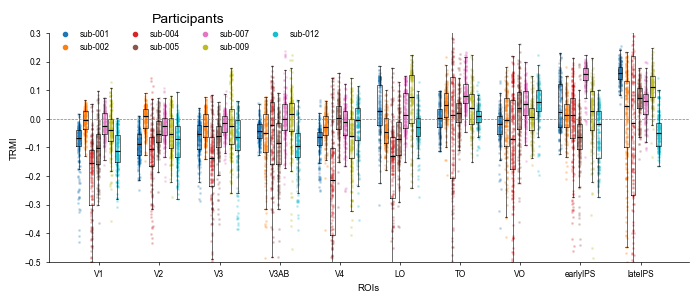

In [10]:
# plot beta sparsity distributions for all subjects across all ROIs in one figure
roi_names = ROIs_list if 'ROIs_list' in globals() else [roi]
n_rois = len(roi_names)
n_subs = len(subjects)
sub_colors = sample_cmap('tab10', n_subs)
rng = np.random.default_rng(42)

# load cross-validated R² once per subject
rsq_all_subs = []
for sub in subjects:
    analysis_result_dir = Path(data_dir) / f"derivatives/prf_data/{sub}/ses-1/{surprise_analysis_type}"
    rsq_sub = np.load(analysis_result_dir / f"{sub}_ses-1_space-fsaverage_surprise-viol_rsq.npy", allow_pickle=True)
    rsq_sub[np.isnan(rsq_sub)] = 0
    rsq_sub[np.isinf(rsq_sub)] = 0
    rsq_all_subs.append(rsq_sub)

fig, ax = plt.subplots(figsize=cm_to_inch(18, 8))
roi_positions = np.arange(n_rois)
subject_offsets = np.linspace(-0.32, 0.32, n_subs)

for roi_idx, roi_name in enumerate(roi_names):
    roi_indices = rois[roi_name] if 'rois' in globals() else cx.get_roi_verts('fsaverage', (roi_name,))[roi_name]
    if len(roi_indices) == 0:
        continue

    for i, sr in enumerate(TRMIs):
        rsq_sub = rsq_all_subs[i]
        rsq_roi = rsq_sub[roi_indices]

        keep_mask = rsq_roi > rsq_threshold
        if not np.any(keep_mask):
            continue

        roi_indices_kept = roi_indices[keep_mask]
        rsq_kept = rsq_roi[keep_mask]

        if len(roi_indices_kept) > nr_best_voxels:
            best_idx_local = np.argsort(rsq_kept)[::-1][:nr_best_voxels]
            best_voxel_indices = roi_indices_kept[best_idx_local]
        else:
            best_voxel_indices = roi_indices_kept

        valid = sr[best_voxel_indices]
        valid = valid[np.isfinite(valid)]
        if len(valid) == 0:
            continue

        pos = roi_positions[roi_idx] + subject_offsets[i]

        jitter = rng.uniform(-0.015, 0.015, size=len(valid))
        ax.scatter(
            pos - 0.02 + jitter,
            valid,
            s=1.2,
            color=sub_colors[i],
            alpha=0.2,
            zorder=2,
            rasterized=True
        )

        # Narrow line-only boxplot (no fill color)
        ax.boxplot(
            valid,
            positions=[pos - 0.02],
            widths=0.08,
            patch_artist=False,
            showfliers=False,
            medianprops=dict(color='k', linewidth=0.8),
            whiskerprops=dict(color='k', linewidth=0.4),
            capprops=dict(color='k', linewidth=0.4),
            boxprops=dict(color='k', linewidth=0.4)
        )

ax.set_xticks(roi_positions)
ax.set_xticklabels(roi_names, rotation=0)
ax.set_ylabel('TRMI')
ax.set_xlabel('ROIs')
ax.axhline(0, color='gray', ls='--', lw=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim(-0.5, 0.3)

# legend for participant colors
legend_handles = [
    plt.Line2D([0], [0], marker='o', linestyle='None', color=sub_colors[i], label=subjects[i], markersize=3)
    for i in range(n_subs)
 ]
ax.legend(handles=legend_handles, title='Participants', ncol=4, frameon=False, loc='upper left', bbox_to_anchor=(0, 1.12))

fig.tight_layout()
plt.show()
fig.savefig(
    figure_result_dir / f"group_analysis-{surprise_analysis_type}_space-fsaverage_desc-prf_viz_allrois_hq-vertex_TRMI-crossvalidatedrsq.png",
    dpi=600,
    bbox_inches='tight'
)